# GOAL: Build linear regression model

In [1]:
#import statements

#import everything!
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime, timedelta
from itertools import product
from copy import deepcopy
from PreRun import PreRun, PostRun
from sklearn.metrics import mean_absolute_error, mean_squared_error
#from statsmodels.tsa.statespace.sarimax import SARIMAX
import random
from sklearn.linear_model import LinearRegression


#path to data
read_path = "../../../../data_ds_project/parquet_cleaned_energy"
#systems
good_systems_list = [4, 10, 33, 36, 50, 51, 1199, 1204, 1283, 1284, 1289, 1332, 4902, 4903]
reader_types = ["meter", "inverter", None]
#systems_cleaned
systems_cleaned = pd.read_csv("../../../data/core/systems_cleaned.csv")


In [2]:
system_id = 4
reader_type = None

prerun = PreRun(system_id = system_id, meter_or_inverter = reader_type, path=read_path, systems_cleaned=systems_cleaned)
prerun.load_data()
prerun.fill_missing_hours()
prerun.add_energy_features_only(daily_lags = 2, remove_daily_lags_nans=True, include_last_year = True, remove_last_year_nans=True, include_day_of_year_cyclic=True, include_hour_cyclic=True)

prerun.add_weather_features_only()

prerun.amended_data = prerun.amended_data.dropna()
# all_data = prerun.amended_data
# end_days = prerun.good_days
#print(end_days)

# big_train_dates, big_test_dates = end_days.iloc[:int(len(end_days)*0.8)]['date'], end_days.iloc[int(len(end_days)*0.8):]['date']
# big_train_dates = pd.to_datetime(big_train_dates)
# big_test_dates = pd.to_datetime(big_test_dates)
# big_train_dates_set = set(big_train_dates)
# big_test_dates_set = set(big_test_dates)


In [3]:
# #some quick eda

# big_train_data = all_data.loc[all_data['time'].dt.normalize().isin(big_train_dates_set)]

# big_train_data.drop(columns=['time']).corr()


In [4]:
# #some quick EDA

# big_train_data = all_data.loc[all_data['time'].dt.normalize().isin(big_train_dates_set)]

# big_train_data = big_train_data.loc[big_train_data['energy']>0]

# df_sample = big_train_data.sample(n=1000)

# sns.pairplot(df_sample)

In [5]:
# #edit this part!!!
# error_list = []
# testing_dates = big_test_dates_set #edit this when it comes to making folds
# for pred_date in testing_dates:
#     train_data = all_data.loc[(all_data['time'] < pred_date - timedelta(days=1))].reset_index(drop=True)
    
#     ho_data = all_data[(all_data['time'].dt.normalize() == pd.to_datetime(pred_date))].reset_index(drop=True)
    

#     linReg = LinearRegression()
#     linReg.fit(train_data.drop(columns=['energy', 'time']), train_data['energy'])
#     y_pred = linReg.predict(ho_data.drop(columns=['energy', 'time']))
#     error = PostRun.custom_error(ho_data['energy'], y_pred)
    
#     error_list.append(error)

In [6]:
# print(np.mean(error_list))
# error_list

In [7]:
# FOR CROSS VALIDATION
# run TTS
# figure out grid of hyperparameters
## create np array -- rows <--> hyperparameters, columns <--> end_date calculated (will end up comparing rows)
# all_errors = -np.ones((# hyperparameter combos, #end_dates))
# for each hyperparameter (i)
#   create model
#   for each train end date (j)
#       extract everything until end date
#       fit model (on date-2 and beforehand)
#       predict  --> keep ONLY the correct day
#       calculate error(y_true, y_pred)
#       put error into grid at location (i,j)

# HOW WELL DID MODEL PERFORM?
# to look at best hyperparameters, find 5 (or some other number) highest averages, look at distributions

In [3]:
prerun.good_end_days_naive(7)
prerun.tts_of_data_using_end_days()

System 4 Linear Regression all error stats:
mean = [0.00265926], std = [0.00459824], min = [0.], max = [0.02646975], median = [0.00055148]


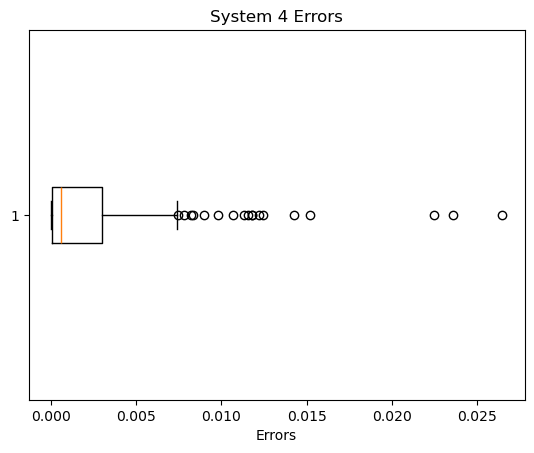

System 4 Linear Regression all error stats:
mean = 0.002868203003175332, std = 0.004712309100574315, min = 3.050029387777777e-08, max = 0.026469753630333017, median = 0.0006426820468174042


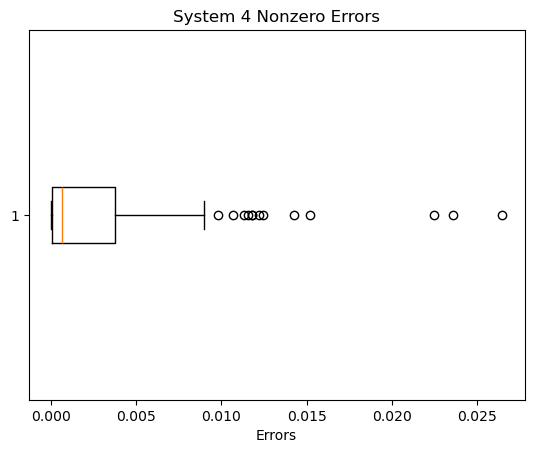

In [ ]:
#no hyperparameters --> 1D array is enough, but will do 2D to make it generalizable
all_errors = -np.ones((1,len(prerun.train_dates)))

linReg = LinearRegression()
i_date = 0
system_recorded_max = prerun.data['energy'].max()
for date in prerun.train_dates['date']:
    #print(type(date))
    data = prerun.data_until_ho_day(date)
    data_train = data.iloc[:-2]
    X_train = data_train.drop(columns = ['time','energy'])
    y_train = data_train['energy']
    data_ho = data.iloc[[-1]]
    X_ho = data_ho.drop(columns = ['time','energy'])
    y_ho = data_ho['energy']
    linReg.fit(X_train, y_train)

    y_pred = linReg.predict(X_ho)
    #make sure value between 0 and highest observed max
    y_pred = np.clip(y_pred, 0, system_recorded_max)
    #make sure that if it's not sunlight hours and irradiance = 0, then energy = 0
    darkness_mask = (~((X_ho['proportion_daytime']==0) & (X_ho['global_tilted_irradiance']==0))).astype(int) # = 0 when both sublight prop and irr are 0
    y_pred = y_pred*np.array(darkness_mask)
    error = PostRun.custom_error(y_ho, y_pred)
    all_errors[0,i_date] = error
    i_date = i_date+1

#calculate mean of each row
hypper_means = np.mean(all_errors, axis=1)
print(f"System {system_id} Linear Regression all error stats:")
print(f"mean = {hypper_means}, std = {np.std(all_errors, axis = 1)}, min = {np.min(all_errors,axis=1)}, max = {np.max(all_errors, axis=1)}, median = {np.median(all_errors,axis=1)}")

#plot
plt.boxplot(all_errors[0], vert=False)  # horizontal → like a number line
plt.xlabel("Errors")
plt.title(f"System {system_id} Errors")
plt.show()

nonzero_errors = all_errors[0]
nonzero_errors = nonzero_errors[nonzero_errors!=0]
print(f"System {system_id} Linear Regression nonzero error stats:")
print(f"mean = {np.mean(nonzero_errors)}, std = {np.std(nonzero_errors)}, min = {np.min(nonzero_errors)}, max = {np.max(nonzero_errors)}, median = {np.median(nonzero_errors)}")
plt.boxplot(nonzero_errors, vert=False)  # horizontal → like a number line
plt.xlabel("Errors")
plt.title(f"System {system_id} Nonzero Errors")
plt.show()


System 1283 Linear Regression all error stats:
mean = [69.54349581], std = [82.21870462], min = [0.], max = [358.89671129], median = [36.20611426]
max entry = 214.57368458333335


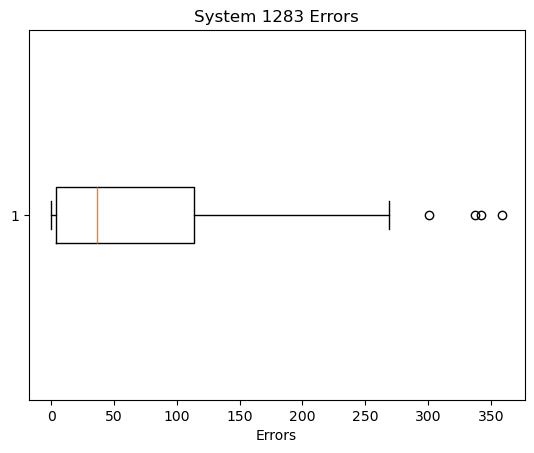

System 1283 Linear Regression all error stats:
mean = 72.34766903140456, std = 82.64149821389515, min = 1.1736995850006942e-10, max = 358.89671128678583, median = 40.03228284024971
max entry = 214.57368458333335


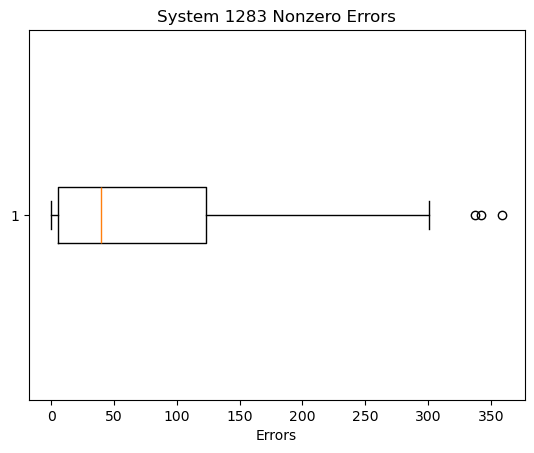

System 1283 Linear Regression all error stats:
mean = [262.96060901], std = [320.47243145], min = [0.], max = [1395.14259512], median = [114.00463679]
max entry = 426.25958333333335


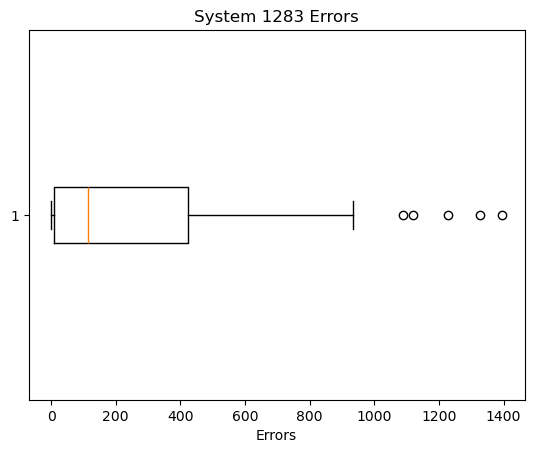

System 1283 Linear Regression all error stats:
mean = 271.4432093025541, std = 322.0450612898095, min = 4.117360576388907e-09, max = 1395.1425951216465, median = 141.35919447143456
max entry = 426.25958333333335


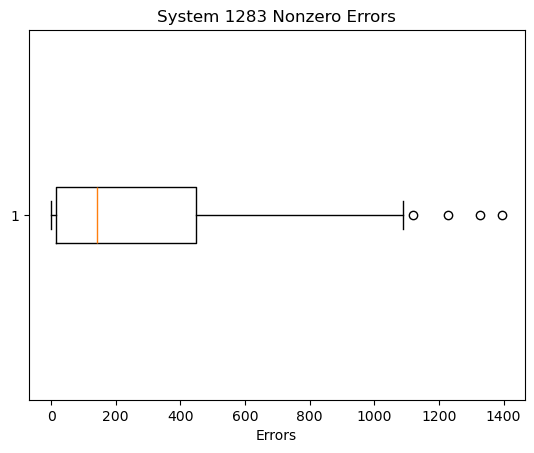

In [7]:
#system_reader_pairs = [(4,None),(10,None), (33, None), (50,None), (51,None), (1283,'inverter'),(1283,'meter')]
system_reader_pairs = [(1283,'inverter'),(1283,'meter')]


for pair in system_reader_pairs:
    system_id = pair[0]
    reader_type = pair[1]

    prerun = PreRun(system_id = system_id, meter_or_inverter = reader_type, path=read_path, systems_cleaned=systems_cleaned)
    prerun.load_data()
        
    prerun.fill_missing_hours()
    prerun.add_energy_features_only(daily_lags = 2, remove_daily_lags_nans=True, include_last_year = True, remove_last_year_nans=True, include_day_of_year_cyclic=True, include_hour_cyclic=True)

    prerun.add_weather_features_only()

    prerun.amended_data = prerun.amended_data.dropna()

    prerun.good_end_days_naive(7)
    prerun.tts_of_data_using_end_days()

    #no hyperparameters --> 1D array is enough, but will do 2D to make it generalizable
    all_errors = -np.ones((1,len(prerun.train_dates)))

    linReg = LinearRegression()
    i_date = 0
    system_recorded_max = prerun.data['energy'].max()
    for date in prerun.train_dates['date']:
        #print(type(date))
        data = prerun.data_until_ho_day(date)
        data_train = data.iloc[:-2]
        X_train = data_train.drop(columns = ['time','energy'])
        y_train = data_train['energy']
        data_ho = data.iloc[[-1]]
        X_ho = data_ho.drop(columns = ['time','energy'])
        y_ho = data_ho['energy']
        linReg.fit(X_train, y_train)

        y_pred = linReg.predict(X_ho)
        #make sure value between 0 and highest observed max
        y_pred = np.clip(y_pred, 0, system_recorded_max)
        #make sure that if it's not sunlight hours and irradiance = 0, then energy = 0
        darkness_mask = (~((X_ho['proportion_daytime']==0) & (X_ho['global_tilted_irradiance']==0))).astype(int) # = 0 when both sublight prop and irr are 0
        y_pred = y_pred*np.array(darkness_mask)
        error = PostRun.custom_error(y_ho, y_pred)
        all_errors[0,i_date] = error
        i_date = i_date+1

    #calculate mean of each row
    hypper_means = np.mean(all_errors, axis=1)
    print(f"System {system_id} Linear Regression all error stats:")
    print(f"mean = {hypper_means}, std = {np.std(all_errors, axis = 1)}, min = {np.min(all_errors,axis=1)}, max = {np.max(all_errors, axis=1)}, median = {np.median(all_errors,axis=1)}")
    print(f"max entry = {system_recorded_max}")

    #plot
    plt.boxplot(all_errors[0], vert=False)  # horizontal → like a number line
    plt.xlabel("Errors")
    plt.title(f"System {system_id} Errors")
    plt.show()

    nonzero_errors = all_errors[0]
    nonzero_errors = nonzero_errors[nonzero_errors!=0]
    print(f"System {system_id} Linear Regression all error stats:")
    print(f"mean = {np.mean(nonzero_errors)}, std = {np.std(nonzero_errors)}, min = {np.min(nonzero_errors)}, max = {np.max(nonzero_errors)}, median = {np.median(nonzero_errors)}")
    print(f"max entry = {system_recorded_max}")
    plt.boxplot(nonzero_errors, vert=False)  # horizontal → like a number line
    plt.xlabel("Errors")
    plt.title(f"System {system_id} Nonzero Errors")
    plt.show()
    